# Event Analysis - 2022 - March


This notebook documents the workflow to use 3DCORE for analysis of a [CME Event in March 2022](https://helioforecast.space/icmecat/ICME_Wind_MOESTL_20220331_01).

It could be associated with the IPS arrival reported in the DONKI database [here](https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/IPS/19607/2), which has 2 linked CMEs.

1. [2022-03-28T12:09:00-CME-001](https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/CME/19556/2)
2. [2022-03-28T20:23:00-CME-001](https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/CME/19574/5)

For simplicity, we will only consider the first CME in this notebook.

In [1]:
from pathlib import Path
import datetime
import pandas as pd

import numpy as np

import re
import urllib

import pickle

from tqdm import tqdm

# suppress warnings
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append(str(Path.cwd().parent)) 

from src.data.data_cache import get_data_cache
from src.methods.utils import get_modelkwargs_ranges
from src.methods.fitting import standard_fit, load_fit_parameters, load_ensemble
from src.methods.plotting import plot_insitu_results, plot_3d_results, propagate_model

import matplotlib.dates as mdates

cache_path = Path.cwd().parent / "cache"


###################################
# settings for plots
###################################

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper')

insitu_colors = ['#c20078','#f97306', '#069af3']

SMALLEST_SIZE = 16
SMALL_SIZE = 20
MEDIUM_SIZE = 22
BIGGER_SIZE = 24

matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.it'] = 'DejaVu Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'DejaVu Sans:bold'

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('axes', titlesize=BIGGER_SIZE)  # fontsize of the figure title


Kernels path loaded: /Volumes/SSDPortable/data/kernels
File names loaded
Data path loaded: /Volumes/SSDPortable/data
Data path loaded: /Volumes/SSDPortable/data


#### Data Preprocessing

We extract the CME from the [CME Scoreboard](https://kauai.ccmc.gsfc.nasa.gov/CMEscoreboard/).

In [2]:
# choose the date range for DONKI query
start_date = datetime.datetime(2022,3,28).strftime('%Y-%m-%d')
end_date = datetime.datetime(2022,3,28).strftime('%Y-%m-%d')

# download DONKI catalog and filter for the CME of interest
url_donki='https://kauai.ccmc.gsfc.nasa.gov/DONKI/WS/get/CMEAnalysis?startDate='+start_date+'&endDate='+end_date+'&mostAccurateOnly=true'
try: urllib.request.urlretrieve(url_donki,cache_path / Path('DONKI.json'))
except urllib.error.URLError as e:
    print('DONKI not loaded')

donkicat = pd.read_json(cache_path / 'DONKI.json')
print(f'# CMEs between {start_date} and {end_date}: ', len(donkicat))

filtered_donki = donkicat[donkicat['associatedCMEID'].str.contains('2022-03-28T12:09:00-CME-001')] # we extract the event with the correct ID
print('# CMEs filtered: ', len(filtered_donki))

# select the first event in the filtered catalog
catalogevent = filtered_donki.iloc[0]

# print the catalog event information
for col in donkicat.columns:
    print(str(col) +': '+ str(catalogevent[col]))

# convert the catalog launch time to a datetime object
dateFormat = "%Y-%m-%dT%H:%MZ"
cataloglaunchtime = datetime.datetime.strptime(catalogevent['time21_5'], dateFormat)

# CMEs between 2022-03-28 and 2022-03-28:  3
# CMEs filtered:  1
time21_5: 2022-03-28T17:19Z
latitude: 7
longitude: 12
halfAngle: 45
speed: 662
type: C
isMostAccurate: True
associatedCMEID: 2022-03-28T12:09:00-CME-001
associatedCMEstartTime: 2022-03-28T12:09Z
note: Final analysis with later imagery.
associatedCMELink: https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/CME/19556/-1
catalog: M2M_CATALOG
featureCode: LE
dataLevel: 1
measurementTechnique: SWPC_CAT
imageType: direct
tilt: nan
minorHalfWidth: nan
speedMeasuredAtHeight: nan
submissionTime: 2022-10-10T19:12Z
versionId: 3
link: https://kauai.ccmc.gsfc.nasa.gov/DONKI/view/CMEAnalysis/19565/-1


#### Wind

In [3]:
idd_wind = 'ICME_Wind_MOESTL_20220331_01' # this is the ID of the event we want to analyze

# one could reduce delta_t_days to reduce computation time during ensemble generation
data_cache_wind = get_data_cache(idd_wind, mean_hours=24, delta_t_days = 3) # mean_hours is the number of hours before the event to calculate the mean solar wind speed

output_path = Path.cwd().parent / "output"
output_folder = output_path / data_cache_wind.idd

No cache found for ICME_Wind_MOESTL_20220331_01, loading data from source
Loading positions data from positions_all_HEEQ_10min_rad_ed.p
File wind_1995_now_gsm.p not found in data path /Volumes/SSDPortable/data, will convert GSM instead of loading.
Loading data from /Volumes/SSDPortable/data
Loaded HEEQ data from wind_1995_now_heeq.p
Loaded RTN data from wind_1995_now_rtn.p
Loaded GSE data from wind_1995_now_gse.p
Converted GSE to GSM data
Position data contains NaNs. Fitting might not be possible.
Data cached for ICME_Wind_MOESTL_20220331_01 at /Users/hannahruedisser/3DCORE-ASWO/cache/ICME_Wind_MOESTL_20220331_01.p


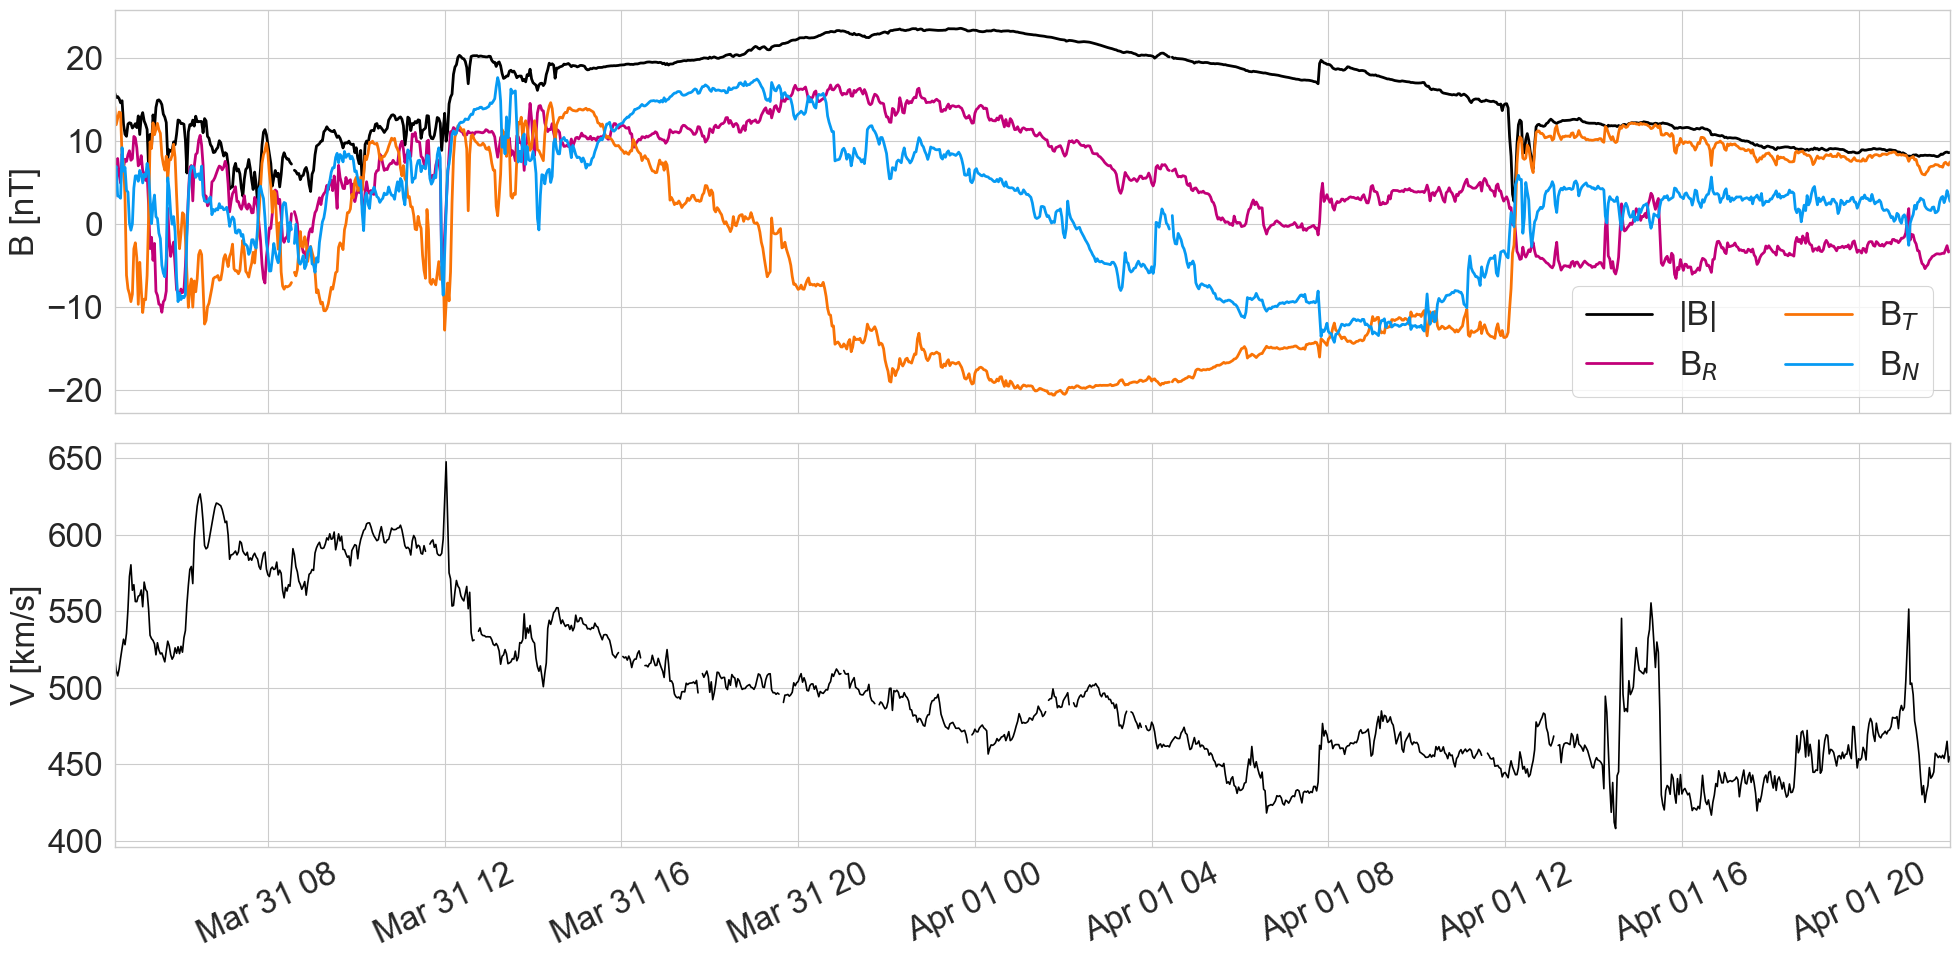

In [7]:
# save the quick insitu plot to the output folder
save_quick_insitu_plot = False

fig, axes = data_cache_wind.quick_insitu_plot(
    reference_frame="RTN", # reference frame for the insitu data ["HEEQ", "RTN", "GSE", "GSM"]
    delta_time_hours=10, # time window around the event to plot
    colors=insitu_colors, 
    figsize=(20,10),
    fontsize=BIGGER_SIZE,
    lw_insitu=2
)

if save_quick_insitu_plot:
    output_folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_folder / f"{data_cache_wind.idd}_insitu_quicklook.png", dpi=200)

fig.show()

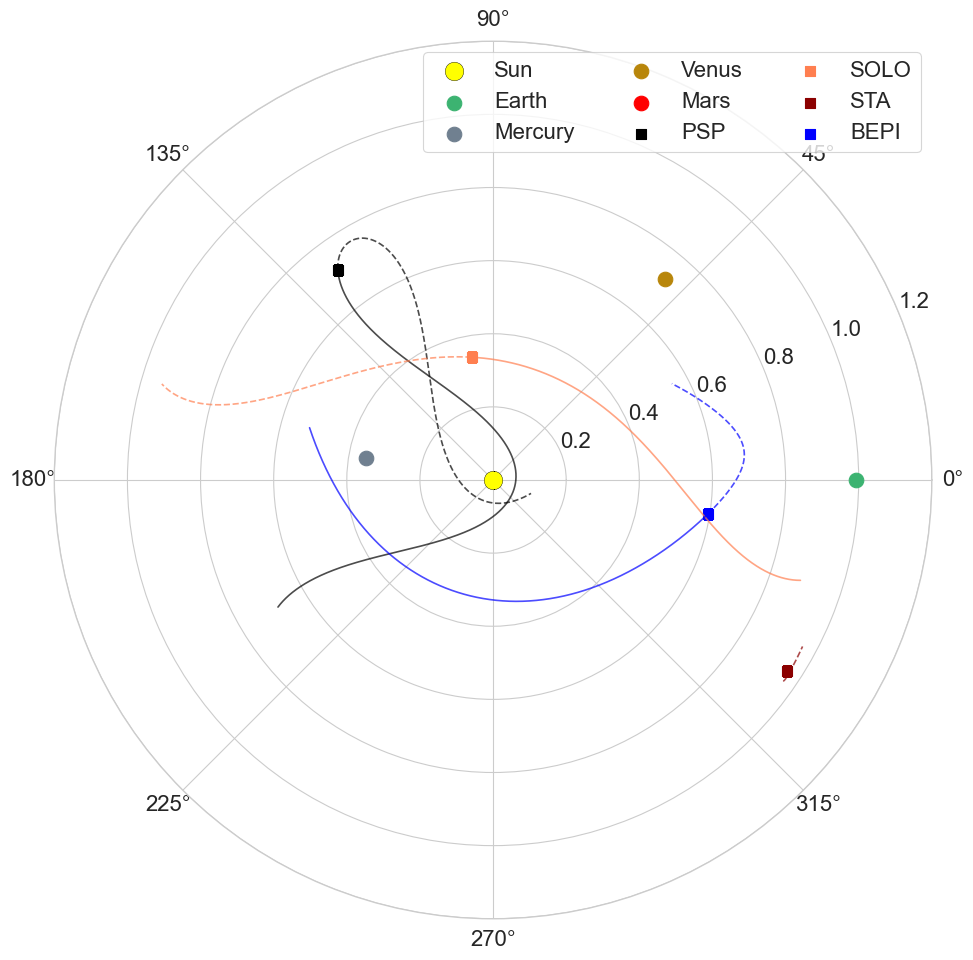

In [8]:
# save the quick positions plot to the output folder
save_quick_positions_plot = False

fig, ax = data_cache_wind.quick_positions_plot(
    fontsize=SMALLEST_SIZE,
    figsize=(20,10)
)

if save_quick_positions_plot:
    output_folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_folder / f"{data_cache_wind.idd}_positions_quicklook.png", dpi=200)

fig.show()

Launch time: 2022-03-28 17:19
MO start time: 2022-03-31 14:32
MO end time: 2022-04-01 12:04
Fitting points: ['2022-03-31 18:07', '2022-03-31 21:42', '2022-04-01 01:18', '2022-04-01 04:53', '2022-04-01 08:28']


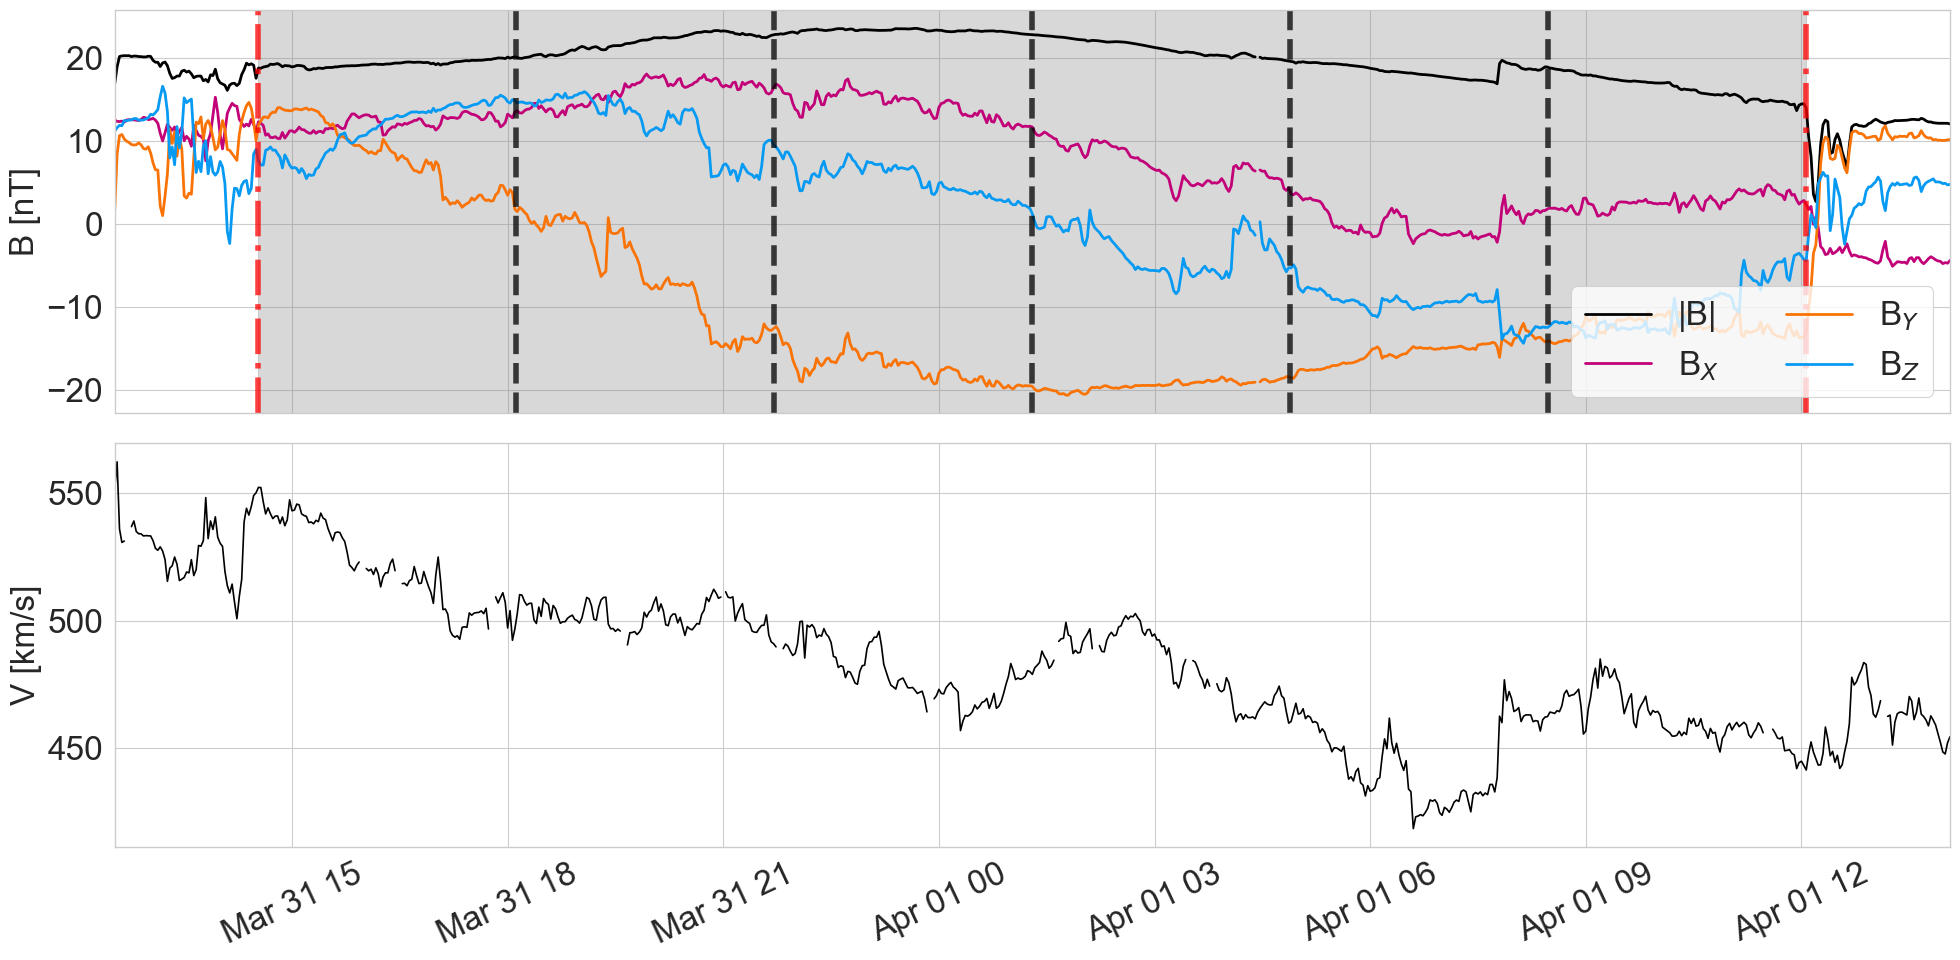

In [17]:
# save the quick fitting points plot to the output folder
save_quick_fitting_points_plot = False

t_launch = cataloglaunchtime.replace(tzinfo=None) # choose launch time, here we use the launch time from the DONKI catalog, but one could also choose a different time

# t_s and t_e are the boundaries outside of which no signatures are allowed. If a set of parameters produces a signature outside of this time window, it will be rejected. If None, the boundaries will be set to the start and end time of the magnetic obstacle as given in the icmecat

t_s = data_cache_wind.mo_begin
t_e = data_cache_wind.endtime


# t_fit will be set as equidistant points between t_s and t_e if None, provide a list of datetime objects to choose different fitting points

t_fit = [
    t_s + (t_e - t_s) * i / 6 for i in range(1,6)
]

fig, axes = data_cache_wind.check_fitting_points(
    t_s, 
    t_e, 
    t_fit, 
    colors=insitu_colors, 
    figsize=(20,10),
    fontsize=BIGGER_SIZE,
    lw_insitu=2,
    lw_fitpts=4
)

if save_quick_fitting_points_plot:
    output_folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_folder / f"{data_cache_wind.idd}_insitu_fittingpoints.png", dpi=200)

print(f"Launch time: {t_launch.strftime('%Y-%m-%d %H:%M')}")
print(f"MO start time: {t_s.strftime('%Y-%m-%d %H:%M')}")
print(f"MO end time: {t_e.strftime('%Y-%m-%d %H:%M')}")
print(f"Fitting points: {[t.strftime('%Y-%m-%d %H:%M') for t in t_fit]}")

In [18]:
longitude_delta = 40
latitude_delta = 30

speed_delta = 100

bg_v_delta = 100
bg_v = data_cache_wind.v_mean_before_event


modelstatevar_ranges = [
    int(2**18) # ensemblesize
    ] + [
        [catalogevent['longitude'] - longitude_delta,catalogevent['longitude']+longitude_delta], # Longitude (HEEQ)
        [catalogevent['latitude'] - latitude_delta,catalogevent['latitude'] +latitude_delta], # Latitude (HEEQ)
        [0.,360.], # Inclination
        [0.05,0.35], # Diameter 1 AU 
        [1.,3.5], # Aspect Ratio  
        [21.5,21.5], # Launch Radius
        [catalogevent['speed'] - speed_delta, catalogevent['speed'] + speed_delta], # Launch Velocity
        [1.,2.0], # Expansion Rate
        [0.20,3.00], # Background Drag
        [bg_v - bg_v_delta, bg_v + bg_v_delta], # Background Velocity
        [-250.,250.], # T_Factor
        [1.,2.], # Magnetic Decay Rate
        [5.,65.], # Magnetic Field Strength 1 AU
    ]

modelkwargs = get_modelkwargs_ranges(modelstatevar_ranges)

multiprocessing = True

njobs = 4

itermin = 12
itermax = 15

n_particles = 512

In [20]:
rerun_fitting = False

fit_number = "last" # "last" or integer

if rerun_fitting:
    extra_args = standard_fit(
        data_cache = data_cache_wind,
        t_launch=t_launch,
        t_s=t_s,
        t_e=t_e,
        t_fit=t_fit,
        model_kwargs=modelkwargs,
        njobs=njobs,
        multiprocessing=multiprocessing,
        itermin=itermin,
        itermax=itermax,
        n_particles=n_particles,
    )

if fit_number == "last":
    fit_files = [
        f for f in output_folder.glob("*.pickle")
        if re.match(r"^\d{2}\.pickle$", f.name)
    ]
    fit_files.sort()

    if fit_files == []:
        print(f"No fitting results found, set rerun_fitting to True")
    else:
        fit_file = fit_files[-1]
else:
    fit_file = output_folder / f"{fit_number:02d}.pickle"

try:
    with open(fit_file, "rb") as fh:
        extra_args = pickle.load(fh)

    print("Loaded fit from file: ", fit_file)
except:
    print(f"Error loading fit results")

Loaded fit from file:  /Users/hannahruedisser/3DCORE-ASWO/output/ICME_Wind_MOESTL_20220331_01/10.pickle


In [22]:
ensemble_data_wind = load_ensemble(output_folder= output_folder, fit_file=fit_file, data_cache=data_cache_wind)

Ensemble path /Users/hannahruedisser/3DCORE-ASWO/output/ICME_Wind_MOESTL_20220331_01/ensemble_10.pickle does not exist, calculating ensemble results...


Calculating ensemble in different coordinate systems:   0%|          | 0/512 [00:00<?, ?it/s]

Saved ensemble to /Users/hannahruedisser/3DCORE-ASWO/output/ICME_Wind_MOESTL_20220331_01/ensemble_10.pickle


In [23]:
results_df_wind, stats_df_wind = load_fit_parameters(fit_file=fit_file, t0=t_launch)

In [24]:
results_df_wind.head()

,Index,RMSE Ɛ,Longitude,Latitude,Inclination,Diameter 1 AU,Aspect Ratio,Launch Radius,Launch Velocity,T_Factor,Expansion Rate,Magnetic Decay Rate,Magnetic Field Strength 1 AU,Background Drag,Background Velocity,Number of Twists,Launch Time
0,0,0.25,2.52,-1.15,334.60,0.17,2.04,21.5,648.51,73.28,1.59,1.45,31.88,2.59,489.61,7.44,2022-03-28 17:19
1,1,0.27,-1.89,-2.66,323.84,0.18,1.05,21.5,607.92,61.92,1.48,1.39,31.44,0.78,467.85,9.61,2022-03-28 17:19
2,2,0.26,-3.12,4.18,337.63,0.18,2.65,21.5,681.74,45.69,1.52,1.40,25.98,0.74,442.79,3.78,2022-03-28 17:19
3,3,0.25,10.63,-5.23,333.17,0.19,2.02,21.5,730.04,59.77,1.27,1.28,31.96,2.38,490.64,6.13,2022-03-28 17:19
4,4,0.27,16.44,-12.15,331.39,0.19,1.22,21.5,756.09,118.41,1.18,1.64,47.67,1.24,493.97,16.95,2022-03-28 17:19


In [25]:
stats_df_wind.head()

,Index,RMSE Ɛ,Longitude,Latitude,Inclination,Diameter 1 AU,Aspect Ratio,Launch Radius,Launch Velocity,T_Factor,Expansion Rate,Magnetic Decay Rate,Magnetic Field Strength 1 AU,Background Drag,Background Velocity,Number of Twists,Launch Time
0,Mean,0.25,6.52,-3.36,325.81,0.18,1.99,21.5,671.21,69.51,1.65,1.48,36.15,0.98,466.87,7.61,2022-03-28 17:19
1,Standard Deviation,0.02,9.96,5.82,6.73,0.02,0.56,0.0,52.92,23.63,0.24,0.28,8.74,0.57,24.40,3.43,2022-03-28 17:19
2,Median,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-03-28 17:19
3,Minimum,0.16,-22.13,-19.86,305.57,0.13,1.02,21.5,565.54,31.06,1.02,1.01,19.26,0.20,363.64,2.35,2022-03-28 17:19
4,Maximum,0.27,30.32,11.53,344.24,0.23,3.47,21.5,761.84,181.81,2.00,2.00,64.19,2.73,495.85,28.06,2022-03-28 17:19


In [26]:
max_col_width = max(len(str(col)) for col in stats_df_wind.columns[2:-1])

for col in stats_df_wind.columns[1:-1]:
    print('{:<{}}{:>20} +/- {:>20}'.format(str(col) + ':', max_col_width + 1, str(stats_df_wind[col][0]), str(stats_df_wind[col][1])))

RMSE Ɛ:                                      0.25 +/-                 0.02
Longitude:                                   6.52 +/-                 9.96
Latitude:                                   -3.36 +/-                 5.82
Inclination:                               325.81 +/-                 6.73
Diameter 1 AU:                               0.18 +/-                 0.02
Aspect Ratio:                                1.99 +/-                 0.56
Launch Radius:                               21.5 +/-                  0.0
Launch Velocity:                           671.21 +/-                52.92
T_Factor:                                   69.51 +/-                23.63
Expansion Rate:                              1.65 +/-                 0.24
Magnetic Decay Rate:                         1.48 +/-                 0.28
Magnetic Field Strength 1 AU:               36.15 +/-                 8.74
Background Drag:                             0.98 +/-                 0.57
Background Velocity:     

In [27]:
row_wind= results_df_wind[results_df_wind['Index']=="Mean"].iloc[0] # extract parameters from mean row


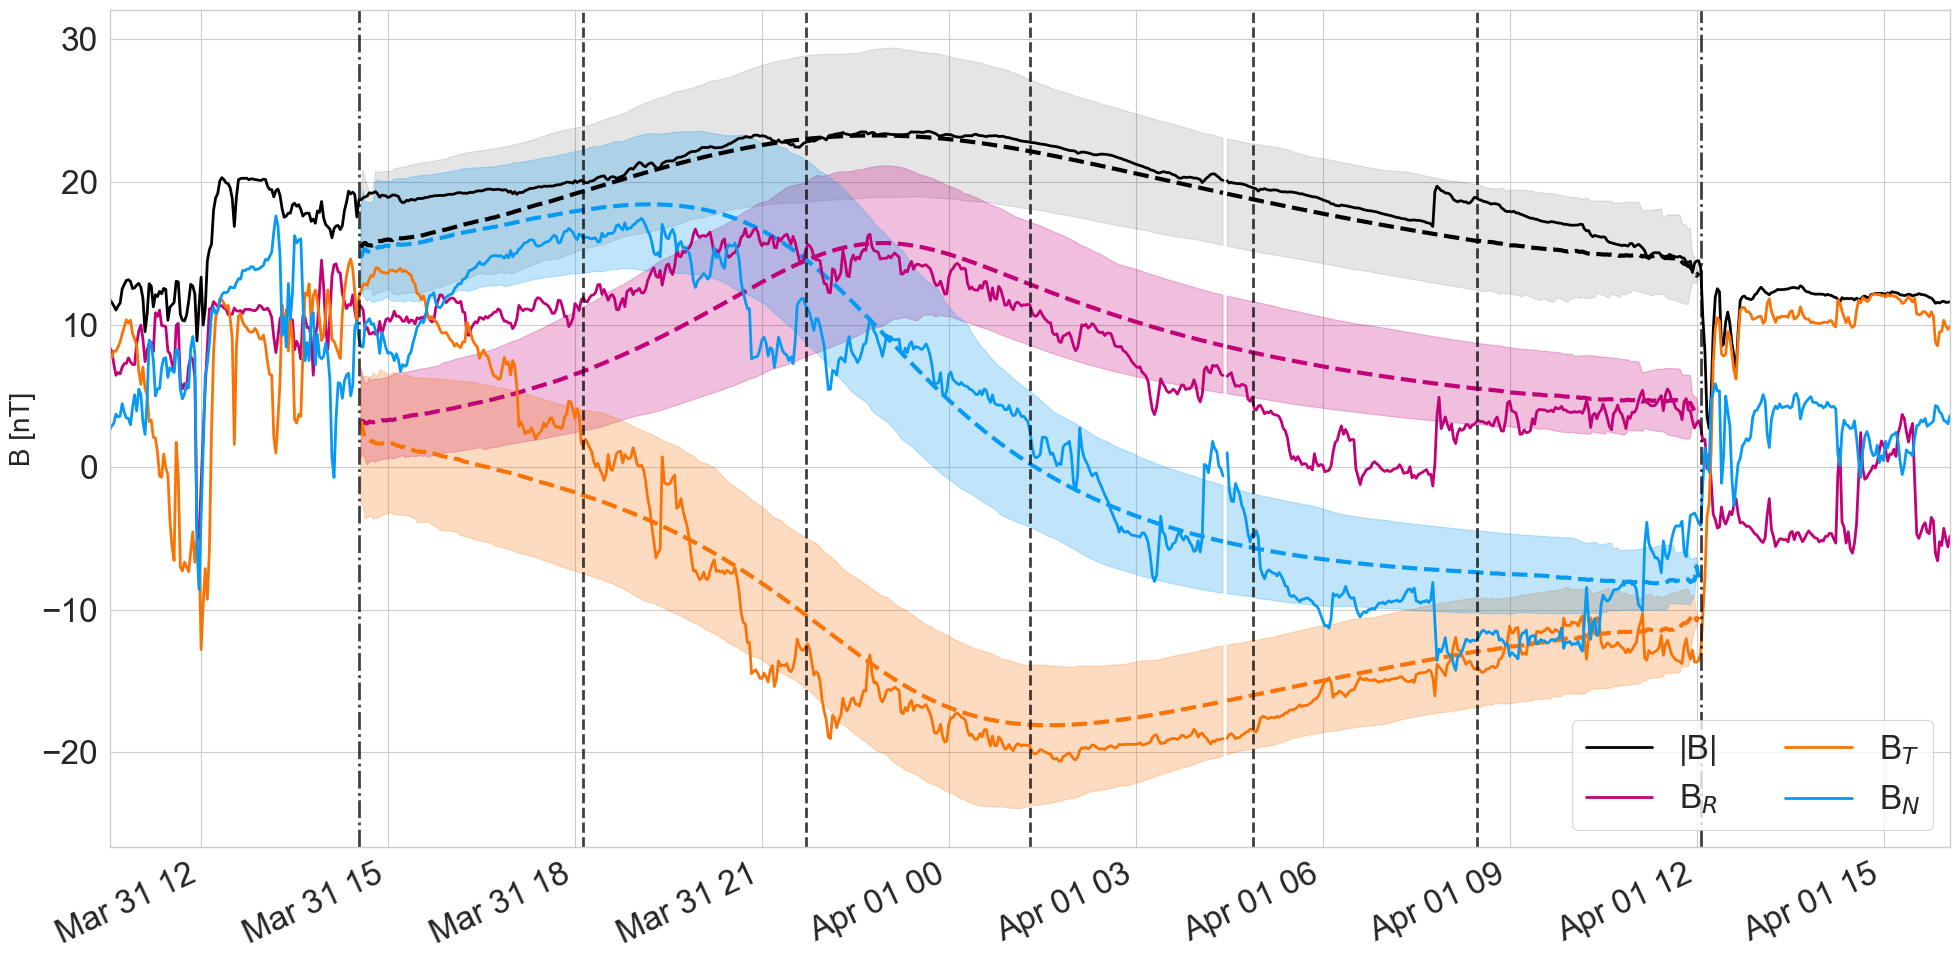

In [28]:
save_quick_results_plot = False

if t_s is not None and t_e is not None:
    insitu_start = t_s - datetime.timedelta(hours=4) # these can be set instead of delta_time_hours
    insitu_end = t_e + datetime.timedelta(hours=4) # these can be set instead of delta_time_hours
else:
    insitu_start = None
    insitu_end = None

fig, ax = plot_insitu_results(
    data_cache=data_cache_wind,
    reference_frame="RTN",
    delta_time_hours=2,
    insitu_start=insitu_start,
    insitu_end=insitu_end,
    t_s = t_s, # set to None if not to be plotted
    t_e = t_e, # set to None if not to be plotted
    t_fit = t_fit, # set to None if not to be plotted
    colors = insitu_colors,
    figsize=(20,10),
    fontsize=BIGGER_SIZE,
    lw_insitu=2,
    lw_best=3,
    lw_mean=3,
    lw_fitpts=2,
    ensemble_data=ensemble_data_wind,
)

if save_quick_results_plot:
    output_folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_folder / f"{data_cache_wind.idd}_insitu_fitresults.png", dpi=200)

In [29]:
# Set new elements for data_cache so they can be used later on

data_cache_wind.row = row_wind

#### 3D Plotting

In [34]:
spacecraft = {
    } 

planets = {
    "earth":"mediumseagreen"
    }

hours_after_launch = 72

t_snap = t_launch + datetime.timedelta(hours=hours_after_launch)

print(f"Plotting snapshot at {t_snap} ({hours_after_launch} hours after launch)")

Plotting snapshot at 2022-03-31 17:19:00 (72 hours after launch)


Plotting wind CME
Tracing Fieldlines
Residuals are not finite in the initial point.
total turns estimates:  7.084210280088751


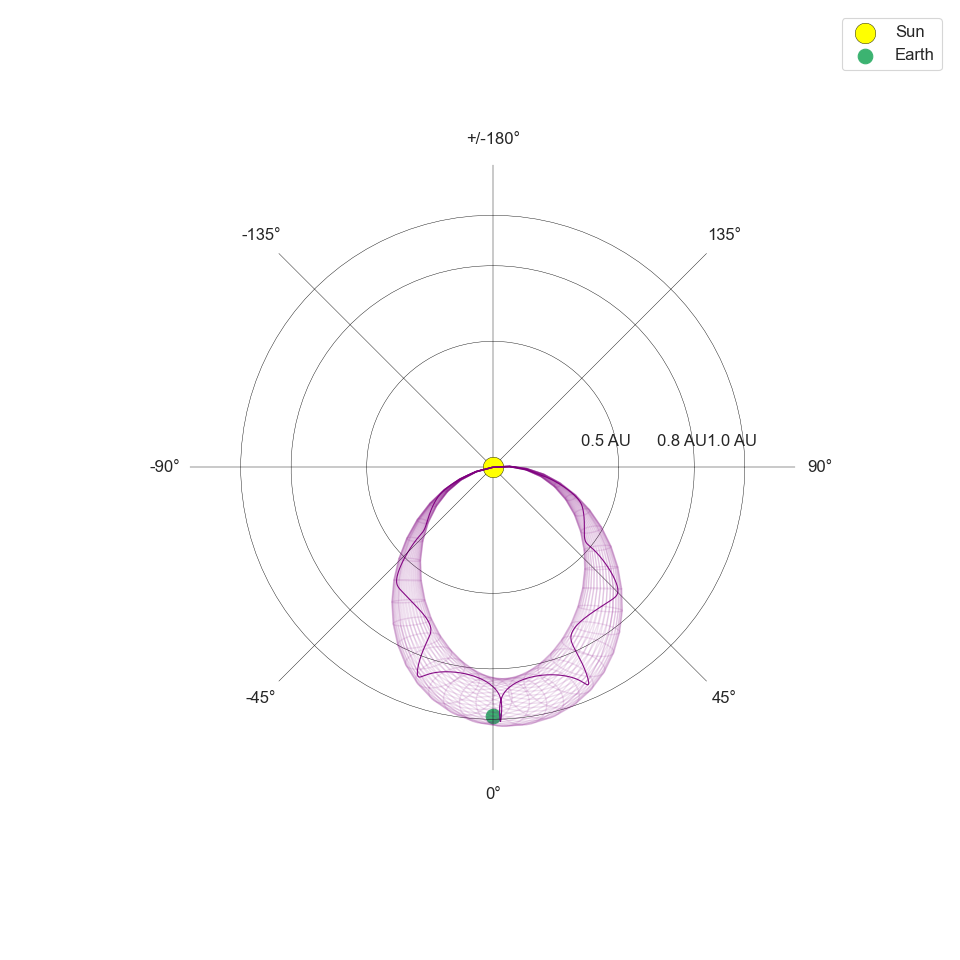

Saved 3D snapshot with azim 0, elev 90, radius 1.2
Plotting wind CME
Tracing Fieldlines
Residuals are not finite in the initial point.
total turns estimates:  7.084210280088751


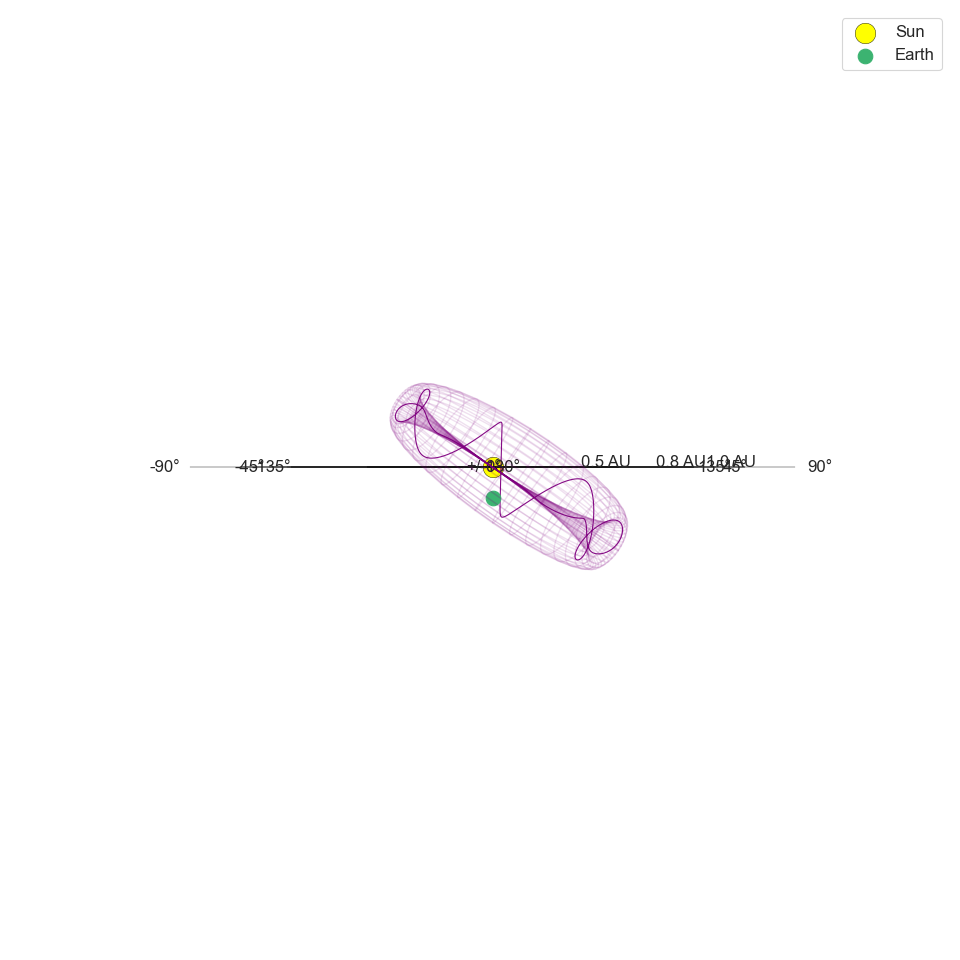

Saved 3D snapshot with azim 0, elev 0, radius 1.2
Plotting wind CME
Tracing Fieldlines
Residuals are not finite in the initial point.
total turns estimates:  7.084210280088751


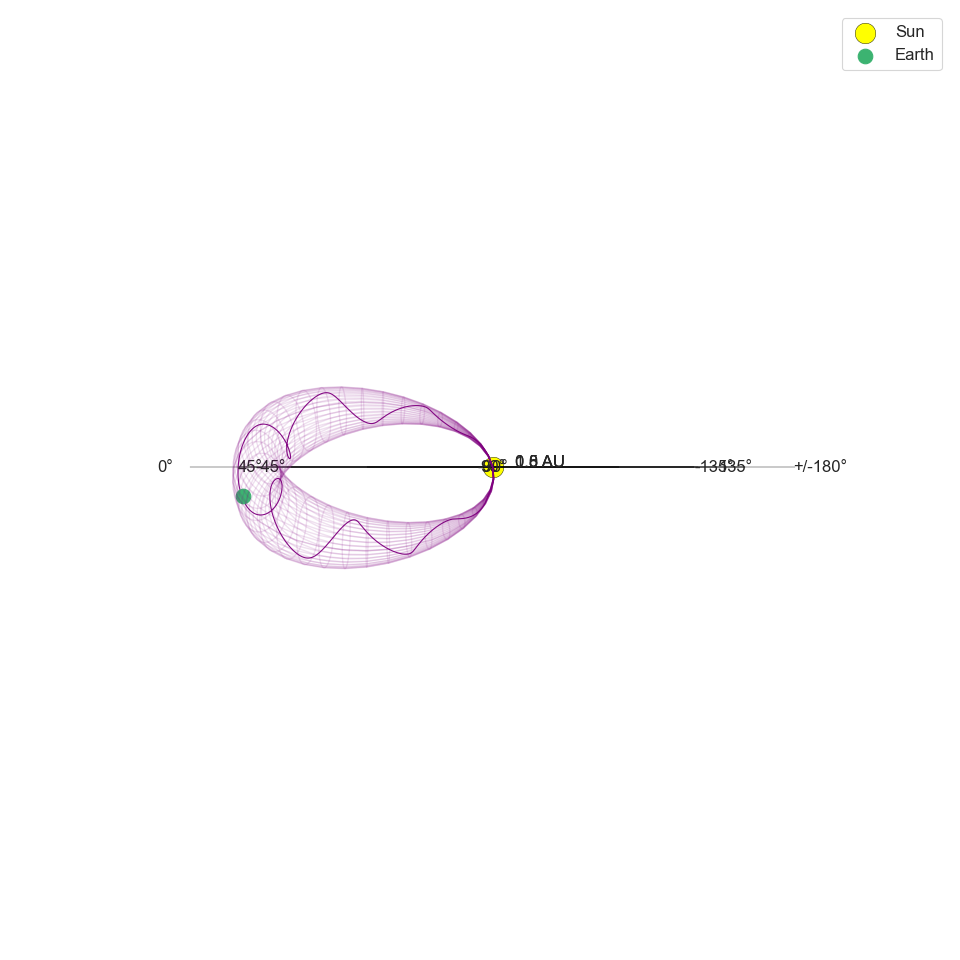

Saved 3D snapshot with azim 90, elev 0, radius 1.2


In [35]:
plot_configs = [
    [0, 90, 1.2],
    [0, 0, 1.2],
    [90, 0, 1.2]
]

save_3d_results_plot = True

for plot_config in plot_configs:

    fig, ax = plot_3d_results(
        data_caches=[
            data_cache_wind
        ], 
        t_snap=t_snap, 
        spacecraft=spacecraft, 
        planets=planets, 
        t_launch=t_launch,
        view_azim = plot_config[0],
        view_elev = plot_config[1],
        view_radius=plot_config[2]
    )
    plt.show()

    if save_3d_results_plot:
        fig.savefig(output_path / f"{t_snap.strftime("%Y-%m-%dT%H:%M")}_3d_snapshot_azim{plot_config[0]}_elev{plot_config[1]}_rad{plot_config[2]}.png", dpi=200)

        print(f"Saved 3D snapshot with azim {plot_config[0]}, elev {plot_config[1]}, radius {plot_config[2]}")
        